In [19]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Q5:How does the combination of socioeconomic barriers and mental health influence the prevalence and management of diabetes?
*** Some code moved from P2 to this notebook for purpose of organizing *** 

In [20]:
data = pd.read_csv("diabetes_dataset.csv")
data2 = pd.read_csv('../diabetes_012_health_indicators_BRFSS2015.csv')


In [21]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [22]:
data2.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [23]:
data2.columns.to_list()

['Diabetes_012',
 'HighBP',
 'HighChol',
 'CholCheck',
 'BMI',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'AnyHealthcare',
 'NoDocbcCost',
 'GenHlth',
 'MentHlth',
 'PhysHlth',
 'DiffWalk',
 'Sex',
 'Age',
 'Education',
 'Income']

Text(0.5, 1.0, 'Diabetes Distribution by Income Level')

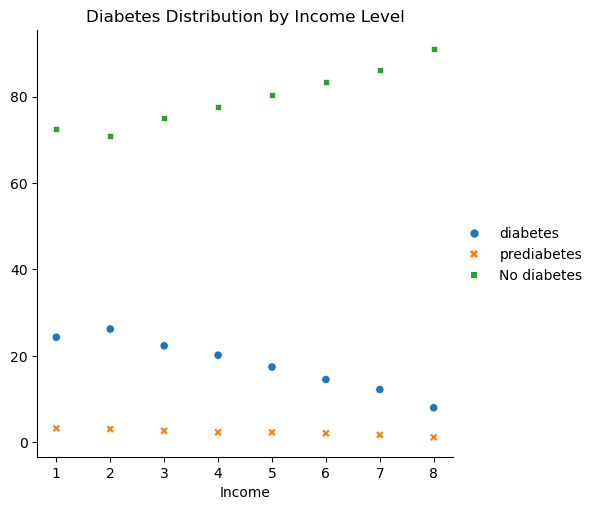

In [24]:
# Using BRFSS for all of Q5
data['dataset_origin'] = 'synthetic'
data2['dataset_origin'] = 'brfss'

# Give proportion by income level
yes_diabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==2].count() / len(x) *100)
prediabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==1].count() / len(x) *100)
no_diabetes = data2.groupby('Income')['Diabetes_012'].apply(lambda x: x[x==0].count() / len(x) *100)

diabetes_proportion = pd.DataFrame({"diabetes": yes_diabetes, 'prediabetes': prediabetes, 'No diabetes': no_diabetes})


sns.relplot(diabetes_proportion)
plt.title("Diabetes Distribution by Income Level")


Text(0.5, 1.0, 'Diabetes Distribution by Poor Mental Health Days')

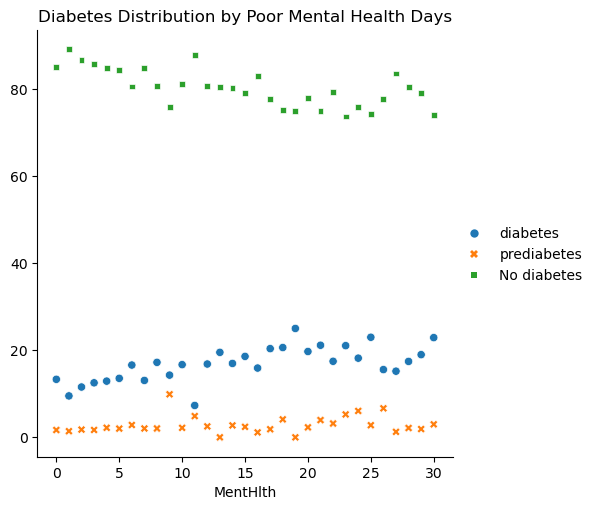

In [25]:
# Diagnosis proportion by number of poor mental health days
mentalHealth3 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==2].count() / len(x) *100)
mentalHealth2 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==1].count() / len(x) *100)
mentalHealth1 = data2.groupby('MentHlth')['Diabetes_012'].apply(lambda x: x[x==0].count() / len(x) *100)

mentHlth_proportion = pd.DataFrame({"diabetes": mentalHealth3, 'prediabetes': mentalHealth2, 'No diabetes': mentalHealth1})
sns.relplot(mentHlth_proportion)
plt.title("Diabetes Distribution by Poor Mental Health Days")

In [26]:
# function to convert to specific ages to age bucket
def combine_age(x):
    if (x > 80):
        return 13.0
    elif (79 >= x >= 75): 
        return 12.0
    elif (74 >= x >= 70):
        return 11.0
    elif (69 >= x >= 65):
        return 10.0
    elif (64 >= x >= 60):
        return 9.0
    elif (59 >= x >= 55):
        return 8.0
    elif (54 >= x >= 50):
        return 7.0
    elif (49 >= x >= 45):
        return 6.0
    elif (44 >= x >= 40):
        return 5.0
    elif (39 >= x >= 35):
        return 4.0
    elif (34 >= x >= 30):
        return 3.0
    elif (29 >= x >= 24):
        return 2.0
    elif (24 >= x >= 19):
        return 1.0

# changes string values of gender to digits
# with 2 being as 'Other'    
def gender_change(x):
    if x == 'Male':
        return 1.0
    elif x == 'Female':
        return 0.0
    else:
        return 2.0

In [27]:
data['age'] = data['age'].apply(combine_age)
data['gender'] = data['gender'].apply(gender_change)
data['gender']

0        1.0
1        0.0
2        1.0
3        0.0
4        1.0
        ... 
99995    1.0
99996    0.0
99997    0.0
99998    0.0
99999    0.0
Name: gender, Length: 100000, dtype: float64

In [28]:
data2.rename(columns={'Age': 'age', 'Education':'education_level', 'Sex':'gender', 'BMI': 'bmi', 'Income':'income_level', 'Smoker': 'smoking_status', 'Diabetes_012': 'diabetes_stage'}, inplace=True)
# data2.info()
combined_data = pd.concat([data,data2])
combined_data.reset_index(inplace=True)
combined_data


,index,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,...,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk
0,0,8.0,1.0,Asian,Highschool,Lower-Middle,Employed,Never,0.0,215.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,6.0,0.0,White,Highschool,Middle,Employed,Former,1.0,143.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,9.0,1.0,Hispanic,Highschool,Middle,Unemployed,Never,1.0,57.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,11.0,0.0,Black,Highschool,Low,Retired,Never,0.0,49.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,6.0,1.0,White,Graduate,Middle,Retired,Never,1.0,109.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353675,253675,5.0,1.0,NaN,6.0,7.0,NaN,0.0,NaN,NaN,...,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0
353676,253676,11.0,0.0,NaN,2.0,4.0,NaN,0.0,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0
353677,253677,2.0,0.0,NaN,5.0,2.0,NaN,0.0,NaN,NaN,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
353678,253678,7.0,1.0,NaN,5.0,1.0,NaN,0.0,NaN,NaN,...,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0


In [29]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353680 entries, 0 to 353679
Data columns (total 48 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   index                               353680 non-null  int64  
 1   age                                 350791 non-null  float64
 2   gender                              353680 non-null  float64
 3   ethnicity                           100000 non-null  object 
 4   education_level                     353680 non-null  object 
 5   income_level                        353680 non-null  object 
 6   employment_status                   100000 non-null  object 
 7   smoking_status                      353680 non-null  object 
 8   alcohol_consumption_per_week        100000 non-null  float64
 9   physical_activity_minutes_per_week  100000 non-null  float64
 10  diet_score                          100000 non-null  float64
 11  sleep_hours_per_day       

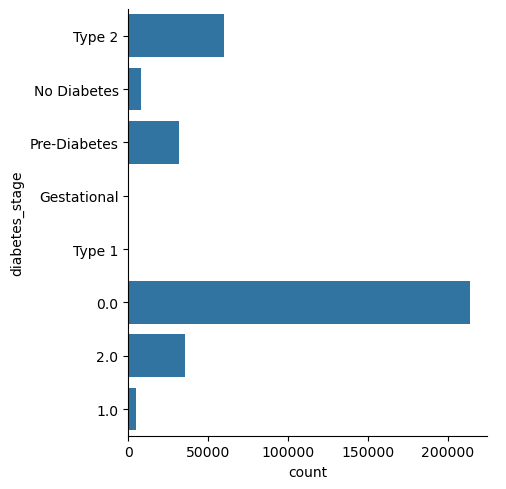

In [30]:
sns.catplot(combined_data, y='diabetes_stage', kind='count')
# This data will need to later be adjusted to accomodate for changes to values to make it compatible

C:\Users\w\AppData\Local\Temp\ipykernel_18476\3875132254.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_mntlhlth0 = data2.groupby(['income_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\3875132254.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_mntlhlth1 = data2.groupby(['income_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\3875132254.py:9: FutureWarning: The default of observed=False is depre

Text(0.5, 1.0, 'Diabetes')

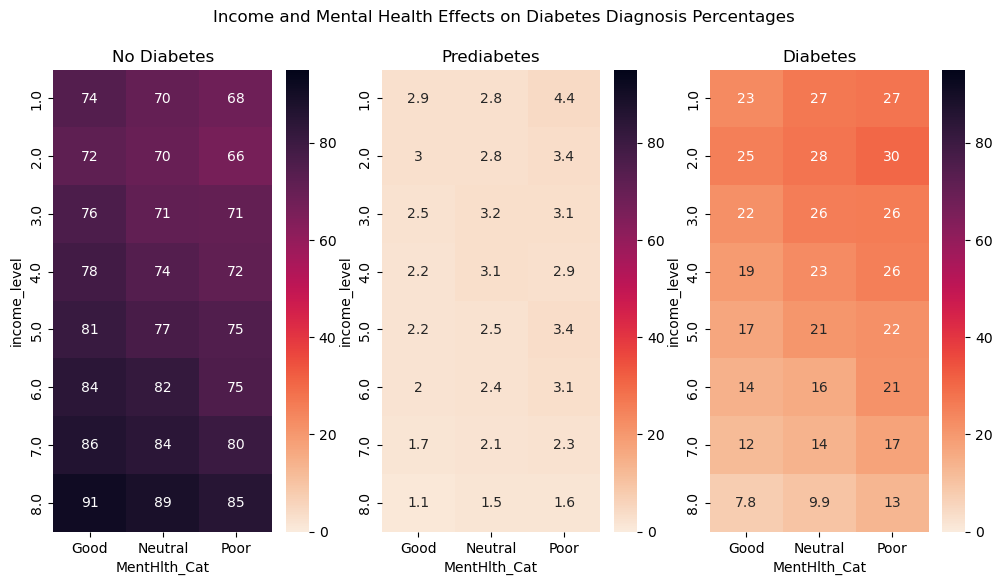

In [31]:



# Binning mental health to reduce number of cells
data2['MentHlth_Cat'] = pd.cut(data2['MentHlth'],
                               bins = [-1, 10,20, 30], # its exclusive on left isde???
                               labels = ['Good', 'Neutral', 'Poor'])

# Heatmap of income level and mental health bin for proportion of a diabetes stage
income_mntlhlth0 = data2.groupby(['income_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
income_mntlhlth1 = data2.groupby(['income_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
income_mntlhlth2 = data2.groupby(['income_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==2].count() / len(x) *100).unstack()
income_mntlhlth0



# To show prevalence of Income + Mental Health on Proportion of Diabetes Diagnosis
fig, axs = plt.subplots(1,3, figsize=(12, 6))
fig.suptitle("Income and Mental Health Effects on Diabetes Diagnosis Percentages")
sns.heatmap(income_mntlhlth0, ax = axs[0], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(income_mntlhlth1, ax = axs[1], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(income_mntlhlth2, ax = axs[2], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
axs[0].set_title('No Diabetes')
axs[1].set_title('Prediabetes')
axs[2].set_title('Diabetes')

# Individuals with higher income are less likely to have diabetes


C:\Users\w\AppData\Local\Temp\ipykernel_18476\2680794571.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_mntlhlth0 = data2.groupby(['education_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\2680794571.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  education_mntlhlth1 = data2.groupby(['education_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\2680794571.py:4: FutureWarning: The default of observed=Fa

Text(0.5, 1.0, 'Diabetes')

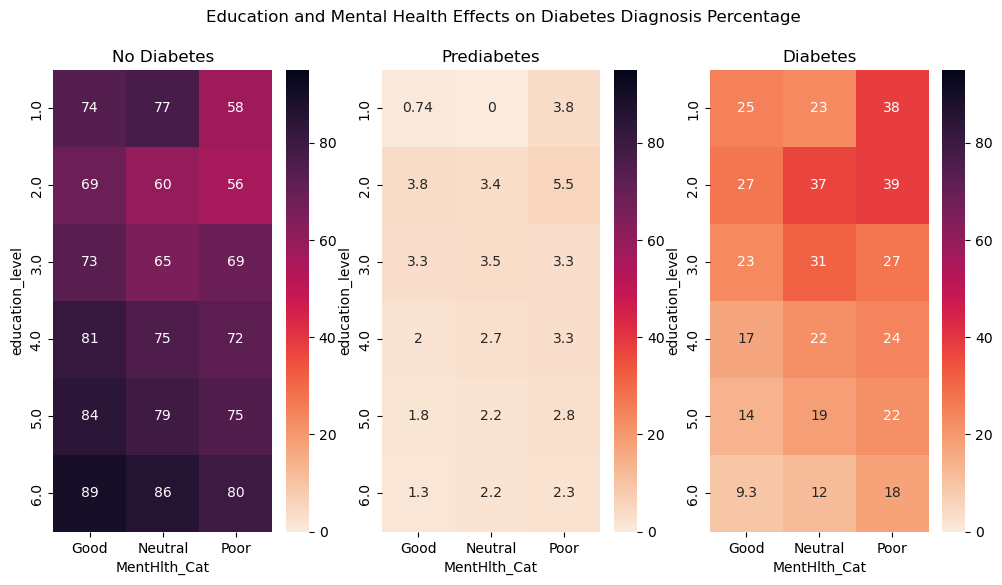

In [32]:
# Education + Mental Health Bins on Proportion of Diabetes Diagnosis
education_mntlhlth0 = data2.groupby(['education_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
education_mntlhlth1 = data2.groupby(['education_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
education_mntlhlth2 = data2.groupby(['education_level','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==2].count() / len(x) *100).unstack()
fig, axs = plt.subplots(1,3, figsize=(12, 6))
fig.suptitle("Education and Mental Health Effects on Diabetes Diagnosis Percentage")
sns.heatmap(education_mntlhlth0, ax = axs[0], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(education_mntlhlth1, ax = axs[1], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(education_mntlhlth2, ax = axs[2], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
axs[0].set_title('No Diabetes')
axs[1].set_title('Prediabetes')
axs[2].set_title('Diabetes')

# individuals with poorer mental health and education appear more likely to have diabetes than individuals with more education
#

C:\Users\w\AppData\Local\Temp\ipykernel_18476\1485540221.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  AnyHealthcare_mntlhlth0 = data2.groupby(['AnyHealthcare','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\1485540221.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  AnyHealthcare_mntlhlth1 = data2.groupby(['AnyHealthcare','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\1485540221.py:4: FutureWarning: The default of observe

Text(0.5, 1.0, 'Diabetes')

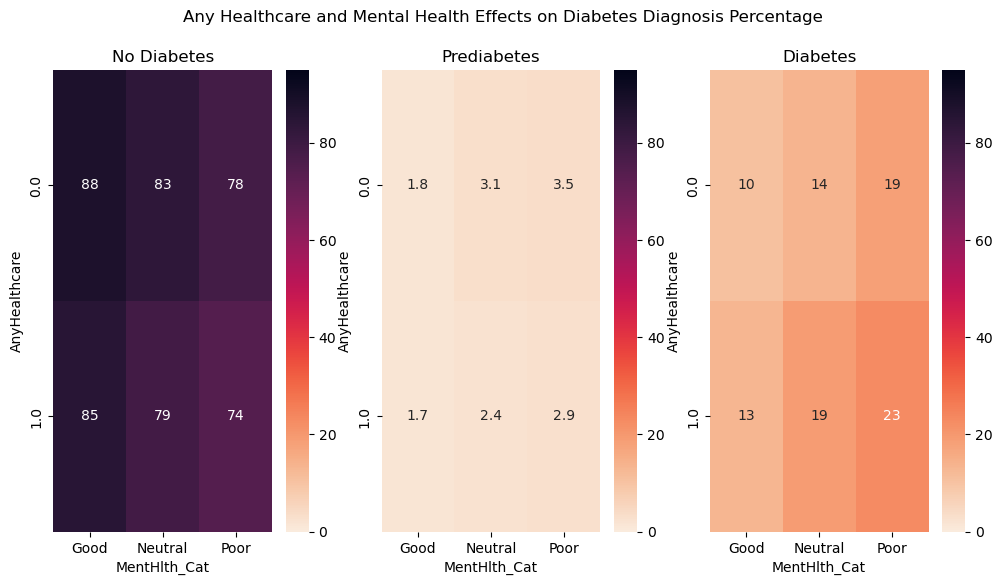

In [33]:
# AnyHealthCare + Mental Health on Proportion of Diabetes Diagnosis
AnyHealthcare_mntlhlth0 = data2.groupby(['AnyHealthcare','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
AnyHealthcare_mntlhlth1 = data2.groupby(['AnyHealthcare','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
AnyHealthcare_mntlhlth2 = data2.groupby(['AnyHealthcare','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==2].count() / len(x) *100).unstack()
fig, axs = plt.subplots(1,3, figsize=(12, 6))
# 1 = having any form of healthcare coverage
fig.suptitle("Any Healthcare and Mental Health Effects on Diabetes Diagnosis Percentage")
sns.heatmap(AnyHealthcare_mntlhlth0, ax = axs[0], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(AnyHealthcare_mntlhlth1, ax = axs[1], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(AnyHealthcare_mntlhlth2, ax = axs[2], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
axs[0].set_title('No Diabetes')
axs[1].set_title('Prediabetes')
axs[2].set_title('Diabetes')
# Interesting: Poor mental health + any health care is more likely proportion to have diabetes
# This could be reflective of more proportion of people who suspect to have diabetes getting diagnosed
# because they have healthcare access.
# Individuals that have diabetes but no healthcare, may avoid getting diagnosed due to costs

C:\Users\w\AppData\Local\Temp\ipykernel_18476\126198144.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  NoDocbcCost_mntlhlth0 = data2.groupby(['NoDocbcCost','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\126198144.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  NoDocbcCost_mntlhlth1 = data2.groupby(['NoDocbcCost','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\126198144.py:4: FutureWarning: The default of observed=False is 

Text(0.5, 1.0, 'Diabetes')

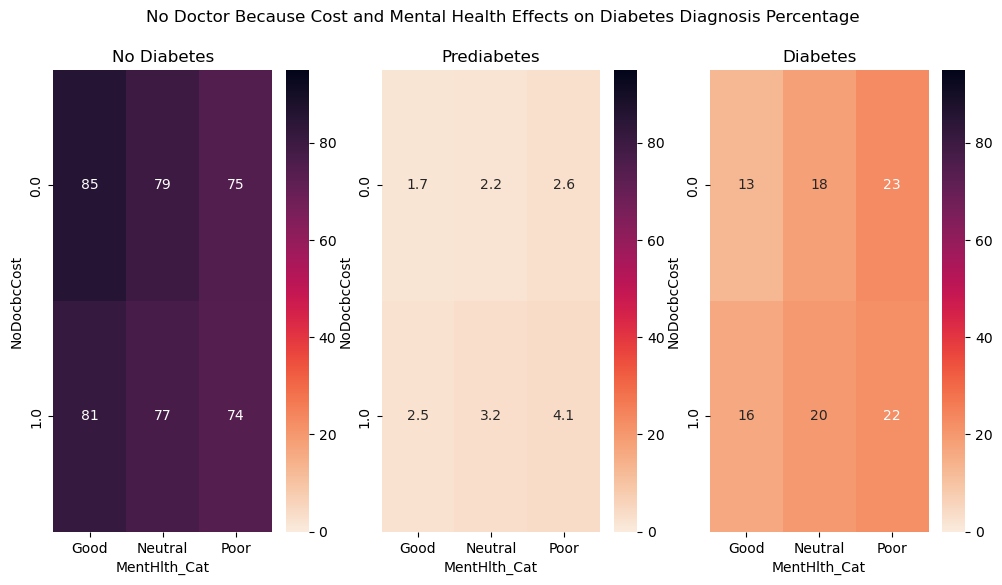

In [34]:
# No Doctor Because Cost and Mental Health
NoDocbcCost_mntlhlth0 = data2.groupby(['NoDocbcCost','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
NoDocbcCost_mntlhlth1 = data2.groupby(['NoDocbcCost','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
NoDocbcCost_mntlhlth2 = data2.groupby(['NoDocbcCost','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==2].count() / len(x) *100).unstack()
fig, axs = plt.subplots(1,3, figsize=(12, 6))

# 1 = yes, instance where couldnt see doctor within last 12 months 
# Rates appear to be similar with or without doctor
fig.suptitle("No Doctor Because Cost and Mental Health Effects on Diabetes Diagnosis Percentage")
sns.heatmap(NoDocbcCost_mntlhlth0, ax = axs[0], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(NoDocbcCost_mntlhlth1, ax = axs[1], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(NoDocbcCost_mntlhlth2, ax = axs[2], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
axs[0].set_title('No Diabetes')
axs[1].set_title('Prediabetes')
axs[2].set_title('Diabetes')

C:\Users\w\AppData\Local\Temp\ipykernel_18476\2060894040.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  PhysActivity_mntlhlth0 = data2.groupby(['PhysActivity','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\2060894040.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  PhysActivity_mntlhlth1 = data2.groupby(['PhysActivity','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
C:\Users\w\AppData\Local\Temp\ipykernel_18476\2060894040.py:5: FutureWarning: The default of observed=Fa

Text(0.5, 1.0, 'Diabetes')

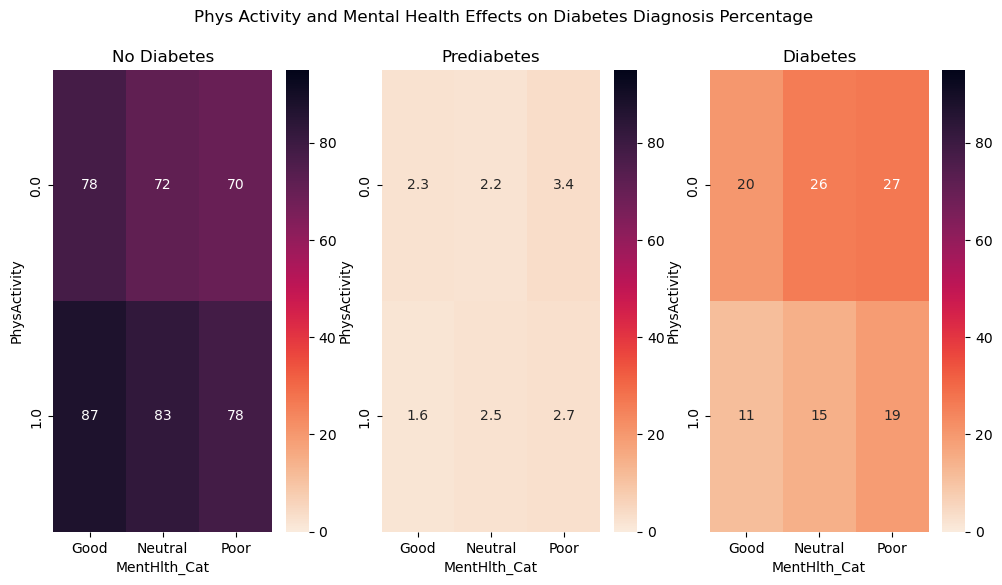

In [35]:
data2['PhysActivity'].value_counts()
# Any Physical Activity in last 30 days and Mental Health
PhysActivity_mntlhlth0 = data2.groupby(['PhysActivity','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==0].count() / len(x) *100).unstack()
PhysActivity_mntlhlth1 = data2.groupby(['PhysActivity','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==1].count() / len(x) *100).unstack()
PhysActivity_mntlhlth2 = data2.groupby(['PhysActivity','MentHlth_Cat'])['diabetes_stage'].apply(lambda x: x[x==2].count() / len(x) *100).unstack()


# No physical activity vs some physical activity appears to demonstrate no physical activity are more likely to have diabetes than any physical activity
# Perhaps 50% to 100 % more in difference among individuals with diabetes surveyed depending on binning of mental health
fig, axs = plt.subplots(1,3, figsize=(12, 6))
fig.suptitle("Phys Activity and Mental Health Effects on Diabetes Diagnosis Percentage")
sns.heatmap(PhysActivity_mntlhlth0, ax = axs[0], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(PhysActivity_mntlhlth1, ax = axs[1], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
sns.heatmap(PhysActivity_mntlhlth2, ax = axs[2], annot=True, vmin= 0, vmax = 95, cmap='rocket_r')
axs[0].set_title('No Diabetes')
axs[1].set_title('Prediabetes')
axs[2].set_title('Diabetes')